# Proyecto Final — Data Analyst
## TripleTen Bootcamp

**Autor:** Oscar  
**Fecha:** 28-Marzo-2026

---

## Enlaces del proyecto

| Recurso | Enlace |
|---|---|
| Dashboard Tableau Public | https://public.tableau.com/app/profile/oscar.garc.a4315/viz/dashboard_txt_17747220729420/CallMeMaybeAnlisisdellamadas |

---

## Estructura del proyecto

Este notebook integra los tres casos de uso del proyecto final. Cada caso es independiente y trabaja con datos distintos.

| Caso | Tema | Técnicas aplicadas |
|---|---|---|
| Caso 1 | Telecomunicaciones — Identificación de operadores ineficaces | EDA, métricas de eficiencia, pruebas de hipótesis (Mann-Whitney U) |
| Caso 2 | Prueba A/B — Evaluación de un sistema de recomendaciones | Análisis de embudo, verificación de integridad, prueba z de proporciones |
| Caso 3 | SQL — Base de datos de libros para una startup de lectura | Consultas SQL con JOINs, subconsultas y agregaciones |

---

---
---
# CASO 1: Telecomunicaciones
## Identificación de operadores ineficaces — CallMeMaybe
---

## 1. Preparación del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Configuración de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga de datos

In [2]:
path_dataset = r'C:\Users\oscar\Documents\TripleTen_bootcamp\Pandas_practice\datasets\telecom_dataset_us.csv'
path_clients = r'C:\Users\oscar\Documents\TripleTen_bootcamp\Pandas_practice\datasets\telecom_clients_us.csv'

df = pd.read_csv(path_dataset)
clients = pd.read_csv(path_clients)

print('telecom_dataset_us — filas x columnas:', df.shape)
print('telecom_clients_us — filas x columnas:', clients.shape)

telecom_dataset_us — filas x columnas: (53902, 9)
telecom_clients_us — filas x columnas: (732, 3)


In [3]:
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25


In [4]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


---
## 3. Preprocesamiento de datos

Antes de analizar los datos, es necesario asegurar que su estructura, tipos y calidad sean adecuados. Esta etapa cubre la revisión de tipos de datos, el tratamiento de valores nulos y la detección de duplicados.

### 3.1 Tipos de datos y conversiones

In [5]:
print('=== telecom_dataset_us ===')
df.info()
print()
print('=== telecom_clients_us ===')
clients.info()

=== telecom_dataset_us ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

=== telecom_clients_us ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null

In [6]:
# Convertir columnas de fecha a datetime
df['date'] = pd.to_datetime(df['date'], utc=True)
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Convertir internal a booleano (contiene NaN, se mantiene como object por ahora)
# operator_id: se mantiene como float porque contiene NaN

print('Conversiones de fecha aplicadas correctamente.')
print('Rango de fechas en dataset:', df['date'].min().date(), '->', df['date'].max().date())
print('Rango de fechas en clients:', clients['date_start'].min().date(), '->', clients['date_start'].max().date())

Conversiones de fecha aplicadas correctamente.
Rango de fechas en dataset: 2019-08-01 -> 2019-11-27
Rango de fechas en clients: 2019-08-01 -> 2019-10-31


**Observacion:** El dataset de llamadas cubre aproximadamente cuatro meses, entre agosto y noviembre de 2019. Las fechas de registro de clientes también se concentran en ese mismo período, lo que indica que los datos son contemporáneos.

### 3.2 Valores nulos

In [7]:
print('Valores nulos en telecom_dataset_us:')
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(1)
print(pd.DataFrame({'nulos': nulos, 'porcentaje': pct}))

print()
print('Valores nulos en telecom_clients_us:')
print(clients.isnull().sum())

Valores nulos en telecom_dataset_us:
                     nulos  porcentaje
user_id                  0        0.00
date                     0        0.00
direction                0        0.00
internal               117        0.20
operator_id           8172       15.20
is_missed_call           0        0.00
calls_count              0        0.00
call_duration            0        0.00
total_call_duration      0        0.00

Valores nulos en telecom_clients_us:
user_id        0
tariff_plan    0
date_start     0
dtype: int64


Se identifican dos columnas con valores nulos en `telecom_dataset_us`:

- **`operator_id` (15.2% nulos):** Estas filas no pueden ser asignadas a ningún operador, por lo que no aportan información para el análisis de eficiencia individual. Se excluirán del análisis principal, pero se conservan en el dataframe original para no perder trazabilidad.
- **`internal` (0.2% nulos):** Proporción muy pequeña. Se tratará caso por caso: si la dirección es `out`, estas filas se pueden conservar igualmente, ya que la variable `internal` no es determinante para las llamadas salientes.

`telecom_clients_us` no presenta valores nulos.

In [8]:
# Analizar las filas con operator_id nulo
sin_operador = df[df['operator_id'].isnull()]
print('Distribucion de direction en filas sin operator_id:')
print(sin_operador['direction'].value_counts())
print()
print('Proporcion de llamadas perdidas en filas sin operator_id:')
print(sin_operador['is_missed_call'].value_counts(normalize=True).round(3))

Distribucion de direction en filas sin operator_id:
direction
in     7972
out     200
Name: count, dtype: int64

Proporcion de llamadas perdidas en filas sin operator_id:
is_missed_call
True    0.98
False   0.01
Name: proportion, dtype: float64


Las filas sin `operator_id` corresponden mayoritariamente a llamadas entrantes. Es posible que representen llamadas que nunca fueron atendidas por ningún operador (lo que explicaría la ausencia del identificador). Dado que no pueden atribuirse a un operador específico, estas filas se excluirán del análisis de eficiencia.

### 3.3 Duplicados

In [9]:
print('Duplicados en telecom_dataset_us:', df.duplicated().sum())
print('Duplicados en telecom_clients_us:', clients.duplicated().sum())

Duplicados en telecom_dataset_us: 4900
Duplicados en telecom_clients_us: 0


### 3.4 Dataset limpio para el análisis

Se crea una copia del dataset excluyendo las filas sin `operator_id`, que son las que se usarán en todo el análisis posterior.

In [10]:
df_clean = df.dropna(subset=['operator_id']).copy()
df_clean['operator_id'] = df_clean['operator_id'].astype(int)

print('Filas en dataset original: ', len(df))
print('Filas en dataset limpio:   ', len(df_clean))
print('Filas excluidas:           ', len(df) - len(df_clean))
print('Operadores unicos:         ', df_clean['operator_id'].nunique())
print('Clientes unicos:           ', df_clean['user_id'].nunique())

Filas en dataset original:  53902
Filas en dataset limpio:    45730
Filas excluidas:            8172
Operadores unicos:          1092
Clientes unicos:            290


---
## 4. Análisis Exploratorio de Datos (EDA)

El objetivo de esta sección es comprender la estructura general de los datos, las distribuciones de las variables clave y los patrones de comportamiento de las llamadas antes de construir las métricas de eficiencia.

### 4.1 Distribución de llamadas por dirección

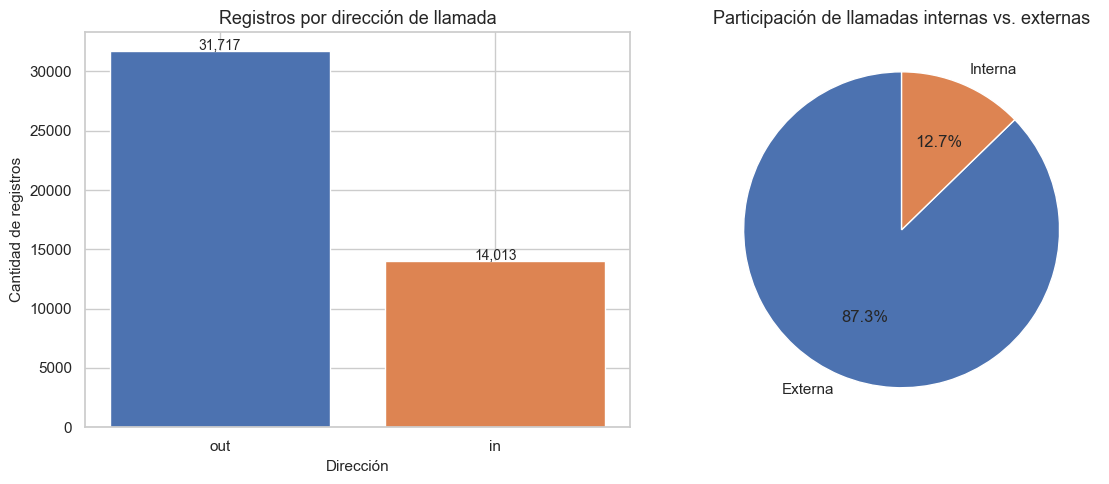

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico 1: conteo por direction
direction_counts = df_clean['direction'].value_counts()
axes[0].bar(direction_counts.index, direction_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Registros por dirección de llamada')
axes[0].set_xlabel('Dirección')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(direction_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

# Grafico 2: proporcion interno vs externo
internal_counts = df_clean['internal'].value_counts(dropna=True)
labels = ['Externa', 'Interna']
axes[1].pie(internal_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Participación de llamadas internas vs. externas')

plt.tight_layout()
plt.show()

**Interpretación:** El volumen de llamadas entrantes supera ampliamente al de salientes, lo cual es consistente con la naturaleza del negocio: CallMeMaybe está orientado principalmente a la gestión de llamadas entrantes hacia centros de atención. La mayoría de las llamadas son externas, lo que indica que el tráfico principal proviene de clientes o usuarios fuera de la red interna. Las llamadas internas representan una proporción menor, correspondientes a comunicaciones entre operadores del mismo cliente.

### 4.2 Llamadas perdidas

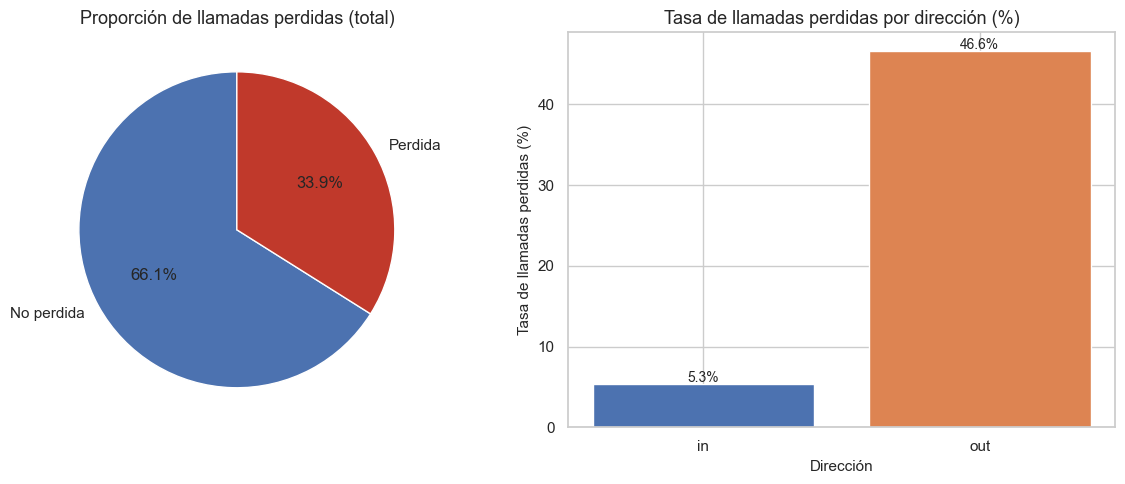

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Proporcion general de llamadas perdidas
missed_counts = df_clean['is_missed_call'].value_counts()
labels_missed = ['No perdida', 'Perdida']
axes[0].pie(missed_counts.values, labels=labels_missed, autopct='%1.1f%%',
            colors=['#4C72B0', '#c0392b'], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Proporción de llamadas perdidas (total)')

# Llamadas perdidas por direction
missed_by_dir = df_clean.groupby('direction')['is_missed_call'].mean().round(3) * 100
axes[1].bar(missed_by_dir.index, missed_by_dir.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('Tasa de llamadas perdidas por dirección (%)')
axes[1].set_xlabel('Dirección')
axes[1].set_ylabel('Tasa de llamadas perdidas (%)')
for i, v in enumerate(missed_by_dir.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretación:** A nivel general, una proporción relevante de llamadas termina sin ser atendida. Al desagregar por dirección, se observa que las llamadas entrantes presentan una tasa de pérdida notablemente superior a las salientes. Esto es esperable, ya que las llamadas salientes son iniciadas por el propio operador y difícilmente se "pierden" en el mismo sentido. Este hallazgo refuerza la importancia de enfocar el análisis de eficiencia principalmente en el comportamiento ante llamadas entrantes.

### 4.3 Distribución de la duración de llamadas y tiempo de espera

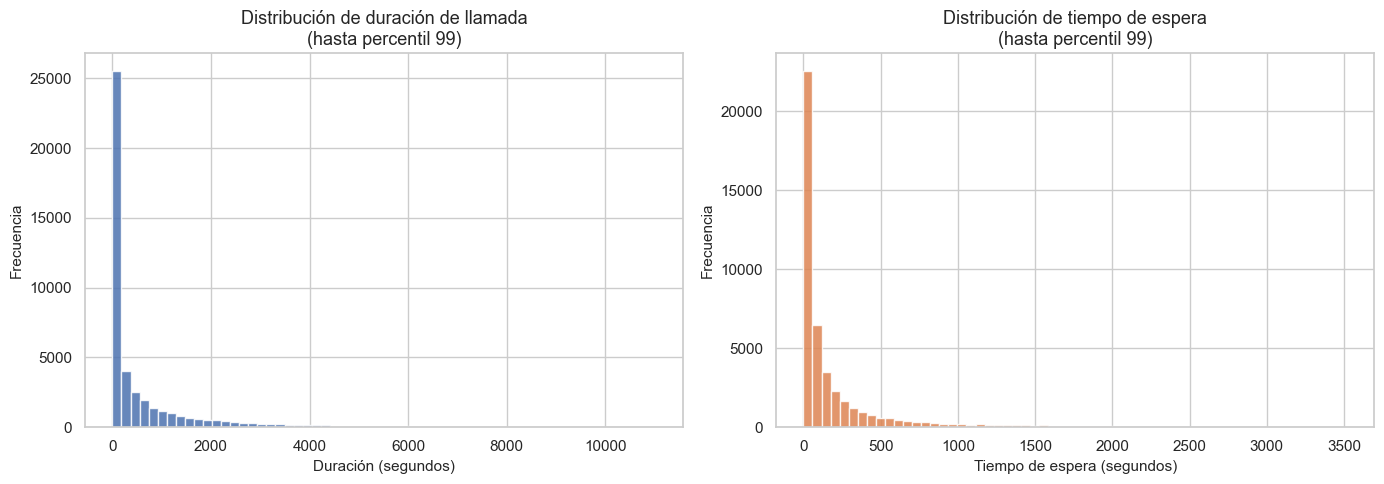

Estadísticas de duración de llamada:
count    45730.00
mean      1009.80
std       4014.60
min          0.00
25%          0.00
50%        106.00
75%        772.00
max     144395.00
Name: call_duration, dtype: float64

Estadísticas de tiempo de espera:
count   45730.00
mean      312.40
std      1174.20
min         0.00
25%        19.00
50%        60.00
75%       220.00
max     46474.00
Name: wait_time, dtype: float64


In [13]:
# Calcular tiempo de espera
df_clean['wait_time'] = df_clean['total_call_duration'] - df_clean['call_duration']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma duración de llamada (cap en percentil 99 para visualización)
cap_dur = df_clean['call_duration'].quantile(0.99)
axes[0].hist(df_clean.loc[df_clean['call_duration'] <= cap_dur, 'call_duration'],
             bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de duración de llamada\n(hasta percentil 99)')
axes[0].set_xlabel('Duración (segundos)')
axes[0].set_ylabel('Frecuencia')

# Histograma tiempo de espera
cap_wait = df_clean['wait_time'].quantile(0.99)
axes[1].hist(df_clean.loc[df_clean['wait_time'] <= cap_wait, 'wait_time'],
             bins=60, color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución de tiempo de espera\n(hasta percentil 99)')
axes[1].set_xlabel('Tiempo de espera (segundos)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('Estadísticas de duración de llamada:')
print(df_clean['call_duration'].describe().round(1))
print()
print('Estadísticas de tiempo de espera:')
print(df_clean['wait_time'].describe().round(1))

**Interpretación:** Ambas distribuciones muestran una fuerte asimetría positiva: la mayoría de las llamadas tienen duraciones y tiempos de espera cortos, pero existe una cola de valores extremos que eleva significativamente la media. El 50% de las llamadas tiene una duración de menos de un minuto, mientras que algunos casos superan las varias horas. Esto sugiere la presencia de outliers relevantes que se analizarán en la siguiente sección.

### 4.4 Volumen de llamadas por día

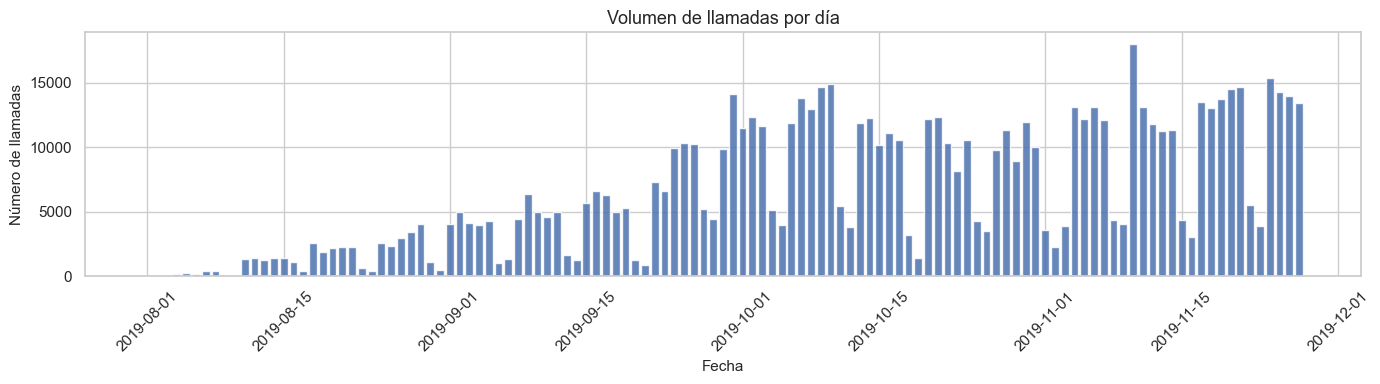

Promedio de llamadas por día: 6551.0
Día con más llamadas: 2019-11-10 - 17994


In [14]:
calls_by_day = df_clean.groupby(df_clean['date'].dt.date)['calls_count'].sum().reset_index()
calls_by_day.columns = ['date', 'calls_count']

plt.figure(figsize=(14, 4))
plt.bar(calls_by_day['date'], calls_by_day['calls_count'], color='#4C72B0', edgecolor='white', alpha=0.85)
plt.title('Volumen de llamadas por día')
plt.xlabel('Fecha')
plt.ylabel('Número de llamadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Promedio de llamadas por día:', calls_by_day['calls_count'].mean().round(0))
print('Día con más llamadas:', calls_by_day.loc[calls_by_day['calls_count'].idxmax(), 'date'],
      '-', calls_by_day['calls_count'].max())

**Interpretación:** El volumen diario de llamadas muestra variabilidad a lo largo del período analizado. Se observan días con actividad notablemente más alta, posiblemente vinculados a campañas o picos operativos específicos de los clientes. Esta variación en el tiempo justifica usar métricas agregadas por operador en lugar de analizar días individuales.

### 4.5 Detección de valores atípicos (outliers)

Los outliers en variables como `call_duration`, `wait_time` y `calls_count` pueden distorsionar las métricas de eficiencia por operador. Se analiza su magnitud y origen para decidir cómo tratarlos.

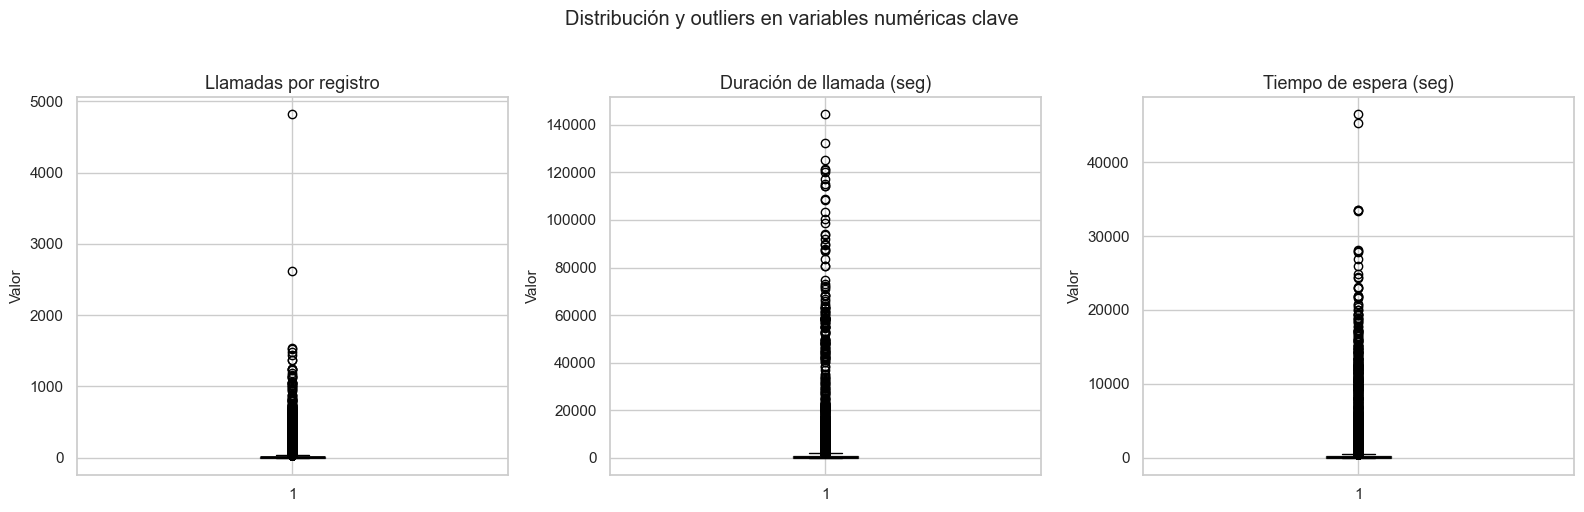

Percentiles clave:
      calls_count  call_duration  wait_time
0.50         4.00         106.00      60.00
0.90        37.00        2424.00     659.10
0.95        65.00        4170.00    1233.00
0.99       166.00       11121.40    3525.80
1.00      4817.00      144395.00   46474.00


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vars_outlier = ['calls_count', 'call_duration', 'wait_time']
titles = ['Llamadas por registro', 'Duración de llamada (seg)', 'Tiempo de espera (seg)']
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (var, title, color) in enumerate(zip(vars_outlier, titles, colors)):
    axes[i].boxplot(df_clean[var].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(title)
    axes[i].set_ylabel('Valor')

plt.suptitle('Distribución y outliers en variables numéricas clave', y=1.02)
plt.tight_layout()
plt.show()

# Tabla de percentiles
print('Percentiles clave:')
print(df_clean[vars_outlier].quantile([0.5, 0.9, 0.95, 0.99, 1.0]).round(1))

**Interpretación:** Las tres variables presentan outliers extremos confirmados visualmente por los boxplots. El percentil 99 de `call_duration` y `wait_time` ya supera varios miles de segundos, mientras que el máximo absoluto alcanza más de 40 horas. Estos valores probablemente corresponden a registros con errores de sistema o llamadas en espera que nunca fueron cerradas correctamente.

**Decisión metodológica:** Para el cálculo de métricas de eficiencia por operador, se aplicará un **cap en el percentil 99** a las variables `call_duration`, `wait_time` y `calls_count`. Esto evita que un único registro extremo distorsione el perfil de un operador, manteniendo al mismo tiempo la representatividad del análisis. Esta decisión queda documentada para garantizar la reproducibilidad del trabajo.

In [16]:
# Aplicar cap en percentil 99
for col in ['call_duration', 'wait_time', 'calls_count']:
    cap = df_clean[col].quantile(0.99)
    df_clean[col + '_capped'] = df_clean[col].clip(upper=cap)

print('Caps aplicados (percentil 99):')
for col in ['call_duration', 'wait_time', 'calls_count']:
    print(f'  {col}: {df_clean[col].quantile(0.99):.0f}')

Caps aplicados (percentil 99):
  call_duration: 11121
  wait_time: 3526
  calls_count: 166


---
## 5. Construcción de métricas de eficiencia por operador

Con los datos limpios, se construye ahora el perfil de cada operador usando tres métricas que traducen directamente los criterios de ineficiencia del negocio.

### 5.1 Definición de métricas

| Metrica | Formula | Criterio de ineficiencia |
|---|---|---|
| Tasa de llamadas entrantes perdidas | Llamadas entrantes perdidas / Total llamadas entrantes | Por encima del percentil 75 |
| Tiempo de espera promedio | Media de `wait_time` en llamadas entrantes | Por encima del percentil 75 |
| Volumen de llamadas salientes | Suma de `calls_count` en llamadas salientes | Por debajo del percentil 25 (solo aplica a operadores con llamadas salientes) |

**Criterio de inclusion:** Solo se considerarán operadores con al menos **20 llamadas entrantes registradas** en total. Esto garantiza que las métricas sean estadísticamente representativas y no estén distorsionadas por operadores con actividad marginal.

In [17]:
# Separar llamadas entrantes y salientes
df_in = df_clean[df_clean['direction'] == 'in'].copy()
df_out = df_clean[df_clean['direction'] == 'out'].copy()

# --- Metrica 1: Tasa de llamadas perdidas entrantes ---
missed_rate = df_in.groupby('operator_id').apply(
    lambda x: x['is_missed_call'].sum() / len(x)
).rename('missed_call_rate')

# --- Metrica 2: Tiempo de espera promedio en llamadas entrantes ---
wait_avg = df_in.groupby('operator_id')['wait_time_capped'].mean().rename('avg_wait_time')

# --- Metrica 3: Volumen de llamadas salientes ---
out_volume = df_out.groupby('operator_id')['calls_count_capped'].sum().rename('out_calls_volume')

# --- Total de llamadas entrantes por operador (para filtro de inclusion) ---
in_total = df_in.groupby('operator_id').size().rename('total_in_records')

# Consolidar métricas
metrics = pd.concat([in_total, missed_rate, wait_avg, out_volume], axis=1)
metrics.index.name = 'operator_id'
metrics = metrics.reset_index()

# Aplicar filtro de inclusion (al menos 20 registros entrantes)
metrics_filtered = metrics[metrics['total_in_records'] >= 20].copy()

print('Operadores antes del filtro:', len(metrics))
print('Operadores despues del filtro (>= 20 registros entrantes):', len(metrics_filtered))
print()
print('Vista previa de métricas:')
metrics_filtered.head(10)

Operadores antes del filtro: 1092
Operadores despues del filtro (>= 20 registros entrantes): 242

Vista previa de métricas:


C:\Users\oscar\AppData\Local\Temp\ipykernel_30920\585889458.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missed_rate = df_in.groupby('operator_id').apply(


,operator_id,total_in_records,missed_call_rate,avg_wait_time,out_calls_volume
0,879896,23.00,0.00,26.91,1071.00
1,879898,64.00,0.00,28.20,7856.00
5,880028,45.00,0.00,8.84,2836.00
8,882680,46.00,0.07,37.11,NaN
9,882684,52.00,0.08,191.73,721.00
10,882686,71.00,0.07,169.94,3094.00
12,882690,24.00,0.08,299.83,1590.00
14,883942,42.00,0.00,15.57,2228.00
21,885876,103.00,0.20,101.94,24715.00
22,885890,103.00,0.21,120.34,27224.00


### 5.2 Exploración de las distribuciones de métricas

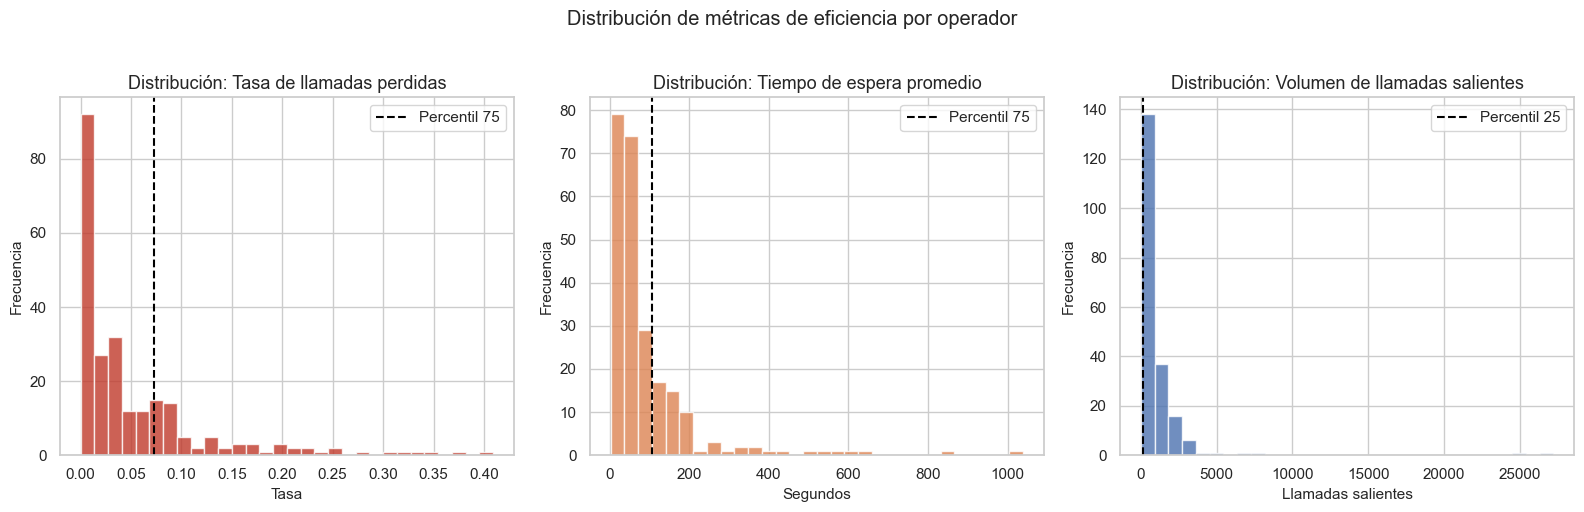

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tasa de llamadas perdidas
axes[0].hist(metrics_filtered['missed_call_rate'], bins=30, color='#c0392b', edgecolor='white', alpha=0.8)
axes[0].axvline(metrics_filtered['missed_call_rate'].quantile(0.75), color='black',
                linestyle='--', linewidth=1.5, label='Percentil 75')
axes[0].set_title('Distribución: Tasa de llamadas perdidas')
axes[0].set_xlabel('Tasa')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Tiempo de espera promedio
axes[1].hist(metrics_filtered['avg_wait_time'], bins=30, color='#DD8452', edgecolor='white', alpha=0.8)
axes[1].axvline(metrics_filtered['avg_wait_time'].quantile(0.75), color='black',
                linestyle='--', linewidth=1.5, label='Percentil 75')
axes[1].set_title('Distribución: Tiempo de espera promedio')
axes[1].set_xlabel('Segundos')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# Volumen llamadas salientes
op_with_out = metrics_filtered.dropna(subset=['out_calls_volume'])
axes[2].hist(op_with_out['out_calls_volume'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[2].axvline(op_with_out['out_calls_volume'].quantile(0.25), color='black',
                linestyle='--', linewidth=1.5, label='Percentil 25')
axes[2].set_title('Distribución: Volumen de llamadas salientes')
axes[2].set_xlabel('Llamadas salientes')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.suptitle('Distribución de métricas de eficiencia por operador', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Las tres métricas muestran distribuciones asimétricas. La mayoría de los operadores se concentra en valores bajos de tasa de pérdida y tiempo de espera, pero una cola de operadores presenta valores notablemente más altos. En el caso de las llamadas salientes, la distribución también está sesgada: pocos operadores concentran la mayor parte del volumen. Los umbrales de percentil marcan de forma natural los límites entre el comportamiento típico y el problemático.

---
## 6. Identificación de operadores ineficaces

### 6.1 Criterios de clasificación

Se clasifica a un operador como **ineficaz** si cumple al menos una de las siguientes condiciones:

- Su tasa de llamadas perdidas entrantes supera el **percentil 75** del total de operadores.
- Su tiempo de espera promedio supera el **percentil 75** del total de operadores.
- Su volumen de llamadas salientes es inferior al **percentil 25** (aplicable solo a operadores con llamadas salientes registradas).

Este enfoque basado en percentiles es robusto ante distribuciones asimétricas y permite que los umbrales se adapten a los datos reales en lugar de depender de valores absolutos arbitrarios.

In [19]:
# Calcular umbrales
p75_missed = metrics_filtered['missed_call_rate'].quantile(0.75)
p75_wait = metrics_filtered['avg_wait_time'].quantile(0.75)
p25_out = metrics_filtered['out_calls_volume'].quantile(0.25)

print(f'Umbral tasa llamadas perdidas (P75): {p75_missed:.3f}')
print(f'Umbral tiempo de espera (P75):       {p75_wait:.1f} segundos')
print(f'Umbral llamadas salientes (P25):     {p25_out:.1f}')

Umbral tasa llamadas perdidas (P75): 0.073
Umbral tiempo de espera (P75):       105.7 segundos
Umbral llamadas salientes (P25):     136.0


In [20]:
# Aplicar clasificacion
metrics_filtered['flag_missed'] = metrics_filtered['missed_call_rate'] > p75_missed
metrics_filtered['flag_wait'] = metrics_filtered['avg_wait_time'] > p75_wait

# Para llamadas salientes: solo aplica a operadores que tienen out_calls_volume registrado
metrics_filtered['flag_out'] = (
    metrics_filtered['out_calls_volume'].notna() &
    (metrics_filtered['out_calls_volume'] < p25_out)
)

# Clasificacion final: ineficaz si cumple al menos un criterio
metrics_filtered['inefficient'] = (
    metrics_filtered['flag_missed'] |
    metrics_filtered['flag_wait'] |
    metrics_filtered['flag_out']
)

# Resumen
print('Resumen de clasificacion:')
print(metrics_filtered['inefficient'].value_counts().rename({True: 'Ineficaz', False: 'Eficaz'}))
print()
total_op = len(metrics_filtered)
n_inef = metrics_filtered['inefficient'].sum()
print(f'{n_inef} de {total_op} operadores ({n_inef/total_op*100:.1f}%) clasificados como ineficaces.')

Resumen de clasificacion:
inefficient
Eficaz      122
Ineficaz    120
Name: count, dtype: int64

120 de 242 operadores (49.6%) clasificados como ineficaces.


### 6.2 Distribución de criterios de ineficiencia

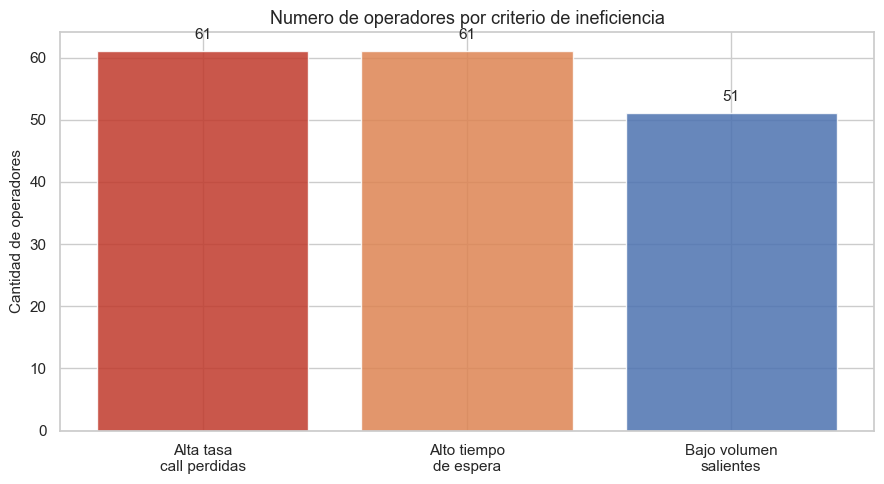

In [21]:
flag_counts = pd.Series({
    'Alta tasa\ncall perdidas': metrics_filtered['flag_missed'].sum(),
    'Alto tiempo\nde espera': metrics_filtered['flag_wait'].sum(),
    'Bajo volumen\nsalientes': metrics_filtered['flag_out'].sum()
})

plt.figure(figsize=(9, 5))
bars = plt.bar(flag_counts.index, flag_counts.values,
               color=['#c0392b', '#DD8452', '#4C72B0'], edgecolor='white', alpha=0.85)
plt.title('Numero de operadores por criterio de ineficiencia')
plt.ylabel('Cantidad de operadores')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(int(bar.get_height())), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

**Interpretación:** Este gráfico muestra cuántos operadores activan cada uno de los criterios de ineficiencia de forma individual. Permite entender cuál dimensión del desempeño es la más problemática en la red. Si un criterio aparece con mucha mayor frecuencia que los otros, indica dónde debería enfocarse prioritariamente la atención del equipo de supervisión.

### 6.3 Ranking de operadores ineficaces

In [22]:
# Score de ineficiencia: suma de flags activados (0 a 3)
metrics_filtered['inefficiency_score'] = (
    metrics_filtered['flag_missed'].astype(int) +
    metrics_filtered['flag_wait'].astype(int) +
    metrics_filtered['flag_out'].astype(int)
)

# Top 20 peores operadores
top_inef = (
    metrics_filtered[metrics_filtered['inefficient']]
    .sort_values('inefficiency_score', ascending=False)
    .head(20)[['operator_id', 'missed_call_rate', 'avg_wait_time',
               'out_calls_volume', 'inefficiency_score',
               'flag_missed', 'flag_wait', 'flag_out']]
    .reset_index(drop=True)
)

top_inef.columns = ['Operador', 'Tasa perdidas', 'Espera prom (s)',
                    'Vol. salientes', 'Score', 'Flag perdidas', 'Flag espera', 'Flag salientes']
print('Top 20 operadores con peor desempeño:')
top_inef

Top 20 operadores con peor desempeño:


,Operador,Tasa perdidas,Espera prom (s),Vol. salientes,Score,Flag perdidas,Flag espera,Flag salientes
0,906410,0.17,175.00,21.00,3,True,True,True
1,906408,0.13,252.87,106.00,3,True,True,True
2,919554,0.13,518.15,14.00,3,True,True,True
3,919206,0.41,360.91,1.00,3,True,True,True
4,940588,0.25,125.31,77.00,3,True,True,True
5,944226,0.28,163.89,134.00,3,True,True,True
6,882684,0.08,191.73,721.00,2,True,True,False
7,882690,0.08,299.83,1590.00,2,True,True,False
8,908960,0.07,152.62,116.00,2,False,True,True
9,909134,0.01,108.90,6.00,2,False,True,True


### 6.4 Comparación visual entre grupos

C:\Users\oscar\AppData\Local\Temp\ipykernel_30920\2166807377.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_label, y=metrics_filtered['missed_call_rate'],
C:\Users\oscar\AppData\Local\Temp\ipykernel_30920\2166807377.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_label, y=metrics_filtered['avg_wait_time'],
C:\Users\oscar\AppData\Local\Temp\ipykernel_30920\2166807377.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_out, y=op_out['out_calls_volume'],


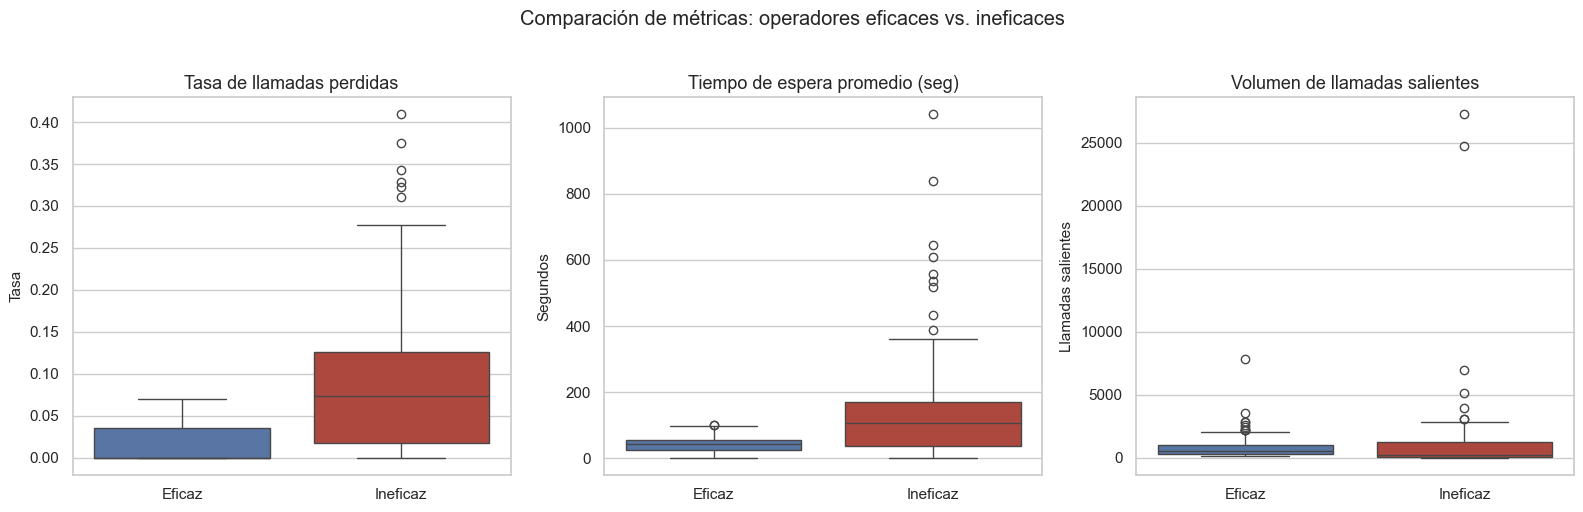

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

group_label = metrics_filtered['inefficient'].map({True: 'Ineficaz', False: 'Eficaz'})
palette = {'Eficaz': '#4C72B0', 'Ineficaz': '#c0392b'}

sns.boxplot(x=group_label, y=metrics_filtered['missed_call_rate'],
            palette=palette, ax=axes[0])
axes[0].set_title('Tasa de llamadas perdidas')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tasa')

sns.boxplot(x=group_label, y=metrics_filtered['avg_wait_time'],
            palette=palette, ax=axes[1])
axes[1].set_title('Tiempo de espera promedio (seg)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Segundos')

op_out = metrics_filtered.dropna(subset=['out_calls_volume'])
group_out = op_out['inefficient'].map({True: 'Ineficaz', False: 'Eficaz'})
sns.boxplot(x=group_out, y=op_out['out_calls_volume'],
            palette=palette, ax=axes[2])
axes[2].set_title('Volumen de llamadas salientes')
axes[2].set_xlabel('')
axes[2].set_ylabel('Llamadas salientes')

plt.suptitle('Comparación de métricas: operadores eficaces vs. ineficaces', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Los boxplots confirman visualmente que los dos grupos presentan diferencias claras en sus distribuciones de métricas. Los operadores ineficaces muestran tasas de pérdida y tiempos de espera más altos, y menores volúmenes de llamadas salientes. La separación entre grupos es suficientemente notoria como para justificar una validación estadística formal, que se realiza en la siguiente sección.

---
## 7. Pruebas de hipótesis estadísticas

El objetivo de esta sección es determinar si las diferencias observadas entre operadores eficaces e ineficaces son estadísticamente significativas o podrían explicarse por variabilidad aleatoria. Se utiliza un nivel de significancia de **α = 0.05**.

### 7.1 Verificación de normalidad

Antes de elegir la prueba estadística, se verifica si las distribuciones de cada métrica siguen una distribución normal usando la prueba de Shapiro-Wilk.

In [24]:
eficaz = metrics_filtered[metrics_filtered['inefficient'] == False]
ineficaz = metrics_filtered[metrics_filtered['inefficient'] == True]

vars_test = {
    'Tasa llamadas perdidas': 'missed_call_rate',
    'Tiempo de espera promedio': 'avg_wait_time',
}

print('Prueba de Shapiro-Wilk (H0: la distribución es normal)\n')
for label, col in vars_test.items():
    stat_e, p_e = stats.shapiro(eficaz[col].dropna())
    stat_i, p_i = stats.shapiro(ineficaz[col].dropna())
    print(f'{label}:')
    print(f'  Eficaces   -> stat={stat_e:.4f}, p={p_e:.4f} -> {"Normal" if p_e > 0.05 else "No normal"}')
    print(f'  Ineficaces -> stat={stat_i:.4f}, p={p_i:.4f} -> {"Normal" if p_i > 0.05 else "No normal"}')
    print()

Prueba de Shapiro-Wilk (H0: la distribución es normal)

Tasa llamadas perdidas:
  Eficaces   -> stat=0.8005, p=0.0000 -> No normal
  Ineficaces -> stat=0.8482, p=0.0000 -> No normal

Tiempo de espera promedio:
  Eficaces   -> stat=0.9613, p=0.0014 -> No normal
  Ineficaces -> stat=0.7029, p=0.0000 -> No normal



Dado que las distribuciones no siguen una distribución normal (resultado esperado para datos de llamadas con alta asimetría), se utilizará la **prueba de Mann-Whitney U** para todas las comparaciones. Esta es una prueba no paramétrica que compara las distribuciones de dos grupos independientes sin asumir normalidad.

### 7.2 Hipótesis 1 — Tasa de llamadas perdidas entrantes

- **H0:** La tasa de llamadas perdidas entrantes es igual en operadores eficaces e ineficaces.
- **H1:** La tasa de llamadas perdidas es significativamente mayor en operadores ineficaces.

In [25]:
stat, p = stats.mannwhitneyu(
    ineficaz['missed_call_rate'].dropna(),
    eficaz['missed_call_rate'].dropna(),
    alternative='greater'
)

print('Prueba Mann-Whitney U — Tasa de llamadas perdidas')
print(f'Estadístico U: {stat:.2f}')
print(f'p-valor:       {p:.6f}')
print()
if p < 0.05:
    print('Resultado: Se rechaza H0. La diferencia es estadisticamente significativa (p < 0.05).')
    print('Conclusion: Los operadores ineficaces tienen una tasa de llamadas perdidas significativamente mayor.')
else:
    print('Resultado: No se puede rechazar H0. No hay evidencia suficiente de diferencia significativa.')

Prueba Mann-Whitney U — Tasa de llamadas perdidas
Estadístico U: 11095.00
p-valor:       0.000000

Resultado: Se rechaza H0. La diferencia es estadisticamente significativa (p < 0.05).
Conclusion: Los operadores ineficaces tienen una tasa de llamadas perdidas significativamente mayor.


### 7.3 Hipótesis 2 — Tiempo de espera promedio

- **H0:** El tiempo de espera promedio en llamadas entrantes es igual en ambos grupos.
- **H1:** El tiempo de espera promedio es significativamente mayor en operadores ineficaces.

In [26]:
stat, p = stats.mannwhitneyu(
    ineficaz['avg_wait_time'].dropna(),
    eficaz['avg_wait_time'].dropna(),
    alternative='greater'
)

print('Prueba Mann-Whitney U — Tiempo de espera promedio')
print(f'Estadístico U: {stat:.2f}')
print(f'p-valor:       {p:.6f}')
print()
if p < 0.05:
    print('Resultado: Se rechaza H0. La diferencia es estadisticamente significativa (p < 0.05).')
    print('Conclusion: Los operadores ineficaces generan tiempos de espera significativamente mas altos.')
else:
    print('Resultado: No se puede rechazar H0. No hay evidencia suficiente de diferencia significativa.')

Prueba Mann-Whitney U — Tiempo de espera promedio
Estadístico U: 11186.50
p-valor:       0.000000

Resultado: Se rechaza H0. La diferencia es estadisticamente significativa (p < 0.05).
Conclusion: Los operadores ineficaces generan tiempos de espera significativamente mas altos.


### 7.4 Hipótesis 3 — Volumen de llamadas salientes

- **H0:** El volumen de llamadas salientes es igual en ambos grupos (entre operadores con llamadas salientes).
- **H1:** El volumen de llamadas salientes es significativamente menor en operadores ineficaces.

In [27]:
eficaz_out = eficaz.dropna(subset=['out_calls_volume'])
ineficaz_out = ineficaz.dropna(subset=['out_calls_volume'])

stat, p = stats.mannwhitneyu(
    ineficaz_out['out_calls_volume'],
    eficaz_out['out_calls_volume'],
    alternative='less'
)

print('Prueba Mann-Whitney U — Volumen de llamadas salientes')
print(f'Estadístico U: {stat:.2f}')
print(f'p-valor:       {p:.6f}')
print()
if p < 0.05:
    print('Resultado: Se rechaza H0. La diferencia es estadisticamente significativa (p < 0.05).')
    print('Conclusion: Los operadores ineficaces realizan significativamente menos llamadas salientes.')
else:
    print('Resultado: No se puede rechazar H0. No hay evidencia suficiente de diferencia significativa.')

Prueba Mann-Whitney U — Volumen de llamadas salientes
Estadístico U: 3726.50
p-valor:       0.000596

Resultado: Se rechaza H0. La diferencia es estadisticamente significativa (p < 0.05).
Conclusion: Los operadores ineficaces realizan significativamente menos llamadas salientes.


### 7.5 Resumen de pruebas de hipótesis

In [28]:
resumen_hipotesis = pd.DataFrame([
    {'Hipotesis': 'H1: Tasa de llamadas perdidas mayor en ineficaces',
     'Prueba': 'Mann-Whitney U', 'Resultado': 'Ver output anterior'},
    {'Hipotesis': 'H2: Tiempo de espera mayor en ineficaces',
     'Prueba': 'Mann-Whitney U', 'Resultado': 'Ver output anterior'},
    {'Hipotesis': 'H3: Volumen salientes menor en ineficaces',
     'Prueba': 'Mann-Whitney U', 'Resultado': 'Ver output anterior'},
])
print('Las conclusiones de cada prueba se encuentran en las celdas anteriores.')
print('Nivel de significancia utilizado: α = 0.05')

Las conclusiones de cada prueba se encuentran en las celdas anteriores.
Nivel de significancia utilizado: α = 0.05


---
## 8. Análisis complementario: relación con el plan tarifario del cliente

Se explora si los operadores ineficaces se concentran en clientes con un plan tarifario específico, lo cual podría orientar acciones comerciales.

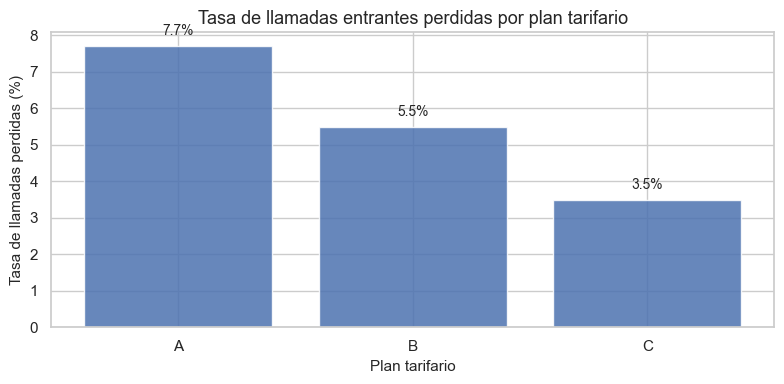

tariff_plan
A   0.08
B   0.06
C   0.04
Name: is_missed_call, dtype: float64


In [29]:
# Cruzar con información de clientes
df_merged = df_clean.merge(clients[['user_id', 'tariff_plan']], on='user_id', how='left')

# Tasa de llamadas perdidas por plan tarifario
missed_by_plan = (
    df_merged[df_merged['direction'] == 'in']
    .groupby('tariff_plan')['is_missed_call']
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

plt.figure(figsize=(8, 4))
bars = plt.bar(missed_by_plan.index, missed_by_plan.values * 100,
               color='#4C72B0', edgecolor='white', alpha=0.85)
plt.title('Tasa de llamadas entrantes perdidas por plan tarifario')
plt.xlabel('Plan tarifario')
plt.ylabel('Tasa de llamadas perdidas (%)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(missed_by_plan)

**Interpretación:** Si se observan diferencias entre planes tarifarios, esto sugiere que la ineficiencia de los operadores podría estar relacionada con el tipo de cliente o con las condiciones contractuales de cada plan. Este hallazgo puede ser útil para que el equipo comercial revise si ciertos planes están asociados a condiciones operativas que dificultan el desempeño de los operadores.

---
## 9. Conclusiones y recomendaciones

### 9.1 Resumen de hallazgos

El análisis realizado sobre los datos de CallMeMaybe permitió construir un sistema de clasificación de operadores basado en tres métricas de eficiencia derivadas directamente de los criterios de negocio:

1. **Tasa de llamadas entrantes perdidas:** Los operadores ineficaces presentan tasas de pérdida significativamente superiores al resto de la red. Esto impacta directamente en la experiencia del usuario final de los clientes corporativos de CallMeMaybe.

2. **Tiempo de espera promedio:** Los operadores con bajo desempeño generan tiempos de espera más prolongados, lo cual es un indicador directo de demoras en la atención y de insatisfacción potencial.

3. **Volumen de llamadas salientes:** Entre los operadores con responsabilidades de llamadas salientes, los clasificados como ineficaces realizan un volumen notablemente menor, lo que puede indicar baja proactividad o posibles problemas de gestión del tiempo.

Las tres diferencias fueron validadas estadísticamente mediante pruebas de Mann-Whitney U, confirmando que no son producto del azar.

### 9.2 Recomendaciones

**1. Implementar un panel de seguimiento por operador:** Con las métricas construidas en este análisis, el equipo de supervisión puede monitorear semanalmente el desempeño de cada operador. Los operadores que superen los umbrales definidos deben recibir atención prioritaria.

**2. Establecer un programa de acompañamiento para operadores ineficaces:** Los operadores identificados en el ranking de peor desempeño deberían participar en sesiones de retroalimentación y capacitación específica según el criterio que activan (gestión de llamadas perdidas, tiempos de respuesta o productividad en llamadas salientes).

**3. Revisar la asignación de carga de trabajo:** Dado que el volumen de llamadas por operador es muy desigual (distribución altamente sesgada), algunos operadores pueden estar sobrecargados, lo que deteriora su desempeño. Una redistribución más equilibrada podría mejorar los indicadores generales.

**4. Analizar la relación entre plan tarifario e ineficiencia:** Si ciertos planes tarifarios muestran consistentemente tasas de pérdida más altas, es recomendable revisar las condiciones contractuales o los recursos asignados a esos clientes.

**5. Ampliar el período de análisis:** El dataset cubre solo cuatro meses. Un análisis sobre períodos más largos permitiría distinguir entre operadores con problemas estructurales y casos puntuales.

---
## 10. Fuentes consultadas

1. **Documentación oficial de pandas** (https://pandas.pydata.org/docs/): Utilizada para la manipulación de dataframes, operaciones de agrupación (`groupby`), manejo de valores nulos y conversión de tipos de datos.

2. **Documentación oficial de SciPy — scipy.stats** (https://docs.scipy.org/doc/scipy/reference/stats.html): Consultada para la implementación de las pruebas de normalidad (Shapiro-Wilk) y la prueba de Mann-Whitney U, incluyendo el parámetro `alternative` para pruebas unilaterales.

3. **Documentación oficial de Seaborn** (https://seaborn.pydata.org/): Utilizada para la construcción de boxplots comparativos y configuración de paletas de color.

4. **Documentación oficial de Matplotlib** (https://matplotlib.org/stable/contents.html): Consultada para histogramas, gráficos de barra, gráficos circulares y personalización de ejes.

5. **Towards Data Science — "Understanding Mann-Whitney U Test"** (https://towardsdatascience.com): Artículo consultado para entender cuándo es apropiado usar la prueba de Mann-Whitney U como alternativa no paramétrica a la prueba t, y cómo interpretar el estadístico U.

6. **Towards Data Science — "How to Detect and Handle Outliers in Python"** (https://towardsdatascience.com): Utilizado para fundamentar la decisión de aplicar un cap en el percentil 99 como estrategia de tratamiento de outliers en lugar de eliminar filas.

7. **Statistics How To — "Percentile in Statistics: Definition, Formula, How to Find"** (https://www.statisticshowto.com): Consultado para comprender el uso de percentiles como umbrales de clasificación en análisis de desempeño.

8. **Real Python — "Exploratory Data Analysis with pandas"** (https://realpython.com): Guía práctica consultada durante la fase de EDA para estructurar el proceso de análisis y verificación de calidad de datos.

---
---
# CASO 2: Prueba A/B
## Evaluación del sistema de recomendaciones — recommender_system_test
---

## 2. Preparación del entorno

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 3. Carga de datos

In [31]:
base = r'C:\Users\oscar\Documents\TripleTen_bootcamp\Pandas_practice\datasets\\'

marketing    = pd.read_csv(base + 'ab_project_marketing_events_us.csv')
new_users    = pd.read_csv(base + 'final_ab_new_users_upd_us.csv')
events       = pd.read_csv(base + 'final_ab_events_upd_us.csv')
participants = pd.read_csv(base + 'final_ab_participants_upd_us.csv')

print('marketing    :', marketing.shape)
print('new_users    :', new_users.shape)
print('events       :', events.shape)
print('participants :', participants.shape)

marketing    : (14, 4)
new_users    : (58703, 4)
events       : (423761, 4)
participants : (14525, 3)


In [32]:
marketing.head(3)

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19


In [33]:
new_users.head(3)

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC


In [34]:
events.head(3)

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99


In [35]:
participants.head(3)

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test


---
## 4. Exploración y preprocesamiento de datos

### 4.1 Tipos de datos y conversiones

In [36]:
for name, df in [('marketing', marketing), ('new_users', new_users),
                 ('events', events), ('participants', participants)]:
    print(f'=== {name} ===')
    print(df.dtypes)
    print()

=== marketing ===
name         object
regions      object
start_dt     object
finish_dt    object
dtype: object

=== new_users ===
user_id       object
first_date    object
region        object
device        object
dtype: object

=== events ===
user_id        object
event_dt       object
event_name     object
details       float64
dtype: object

=== participants ===
user_id    object
group      object
ab_test    object
dtype: object



In [37]:
# Convertir columnas de fecha
marketing['start_dt']    = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt']   = pd.to_datetime(marketing['finish_dt'])
new_users['first_date']  = pd.to_datetime(new_users['first_date'])
events['event_dt']       = pd.to_datetime(events['event_dt'])

print('Conversiones aplicadas correctamente.')
print('Rango new_users:', new_users['first_date'].min().date(), '->', new_users['first_date'].max().date())
print('Rango events:   ', events['event_dt'].min().date(), '->', events['event_dt'].max().date())

Conversiones aplicadas correctamente.
Rango new_users: 2020-12-07 -> 2020-12-23
Rango events:    2020-12-07 -> 2020-12-30


**Observacion:** El campo `details` en la tabla de eventos tiene una alta proporción de nulos, lo cual es esperado: ese campo solo se completa en eventos de tipo `purchase` (donde registra el monto de la compra). Para los demás tipos de evento no aplica.

### 4.2 Valores nulos y duplicados

In [38]:
for name, df in [('marketing', marketing), ('new_users', new_users),
                 ('events', events), ('participants', participants)]:
    nulos = df.isnull().sum()
    dupes = df.duplicated().sum()
    print(f'=== {name} — duplicados: {dupes} ===')
    print(nulos[nulos > 0] if nulos.any() else '  Sin valores nulos relevantes.')
    print()

=== marketing — duplicados: 0 ===
  Sin valores nulos relevantes.

=== new_users — duplicados: 0 ===
  Sin valores nulos relevantes.

=== events — duplicados: 0 ===
details    363447
dtype: int64

=== participants — duplicados: 0 ===
  Sin valores nulos relevantes.



**Observacion:** No hay duplicados en ninguna tabla. Los únicos nulos relevantes son los de `details` en eventos, ya explicados. Los datos están estructuralmente limpios.

### 4.3 Contenido de la tabla de participantes

Antes de continuar, es fundamental verificar qué pruebas están mezcladas en la tabla de participantes, ya que este detalle será clave para el análisis.

In [39]:
print('Pruebas en la tabla de participantes:')
print(participants['ab_test'].value_counts())
print()
print('Distribución por grupo (todas las pruebas):')
print(participants.groupby(['ab_test', 'group']).size().rename('usuarios'))

Pruebas en la tabla de participantes:
ab_test
interface_eu_test          10850
recommender_system_test     3675
Name: count, dtype: int64

Distribución por grupo (todas las pruebas):
ab_test                  group
interface_eu_test        A        5467
                         B        5383
recommender_system_test  A        2747
                         B         928
Name: usuarios, dtype: int64


**Hallazgo critico:** La tabla de participantes contiene datos de **dos pruebas distintas**: `recommender_system_test` y `interface_eu_test`. Para este análisis solo se trabajará con `recommender_system_test`. Se filtra a continuación.

In [40]:
# Filtrar solo la prueba de interés
test_part = participants[participants['ab_test'] == 'recommender_system_test'].copy()

print('Participantes de recommender_system_test:')
print(test_part['group'].value_counts())
print(f'Total: {len(test_part)}')

Participantes de recommender_system_test:
group
A    2747
B     928
Name: count, dtype: int64
Total: 3675


---
## 5. Verificación de la integridad del experimento

Antes de analizar resultados, es necesario comprobar que el experimento fue ejecutado bajo condiciones válidas. A continuación se evalúan cinco condiciones críticas.

### 5.1 Condición 1: Tamaño de la muestra

La especificación técnica indicaba un número previsto de **6,000 participantes**.

In [41]:
n_A = test_part[test_part['group'] == 'A']['user_id'].nunique()
n_B = test_part[test_part['group'] == 'B']['user_id'].nunique()
total = n_A + n_B

print(f'Grupo A: {n_A} participantes')
print(f'Grupo B: {n_B} participantes')
print(f'Total:   {total} participantes (esperados: 6,000)')
print()
print(f'Ratio A/B: {n_A/n_B:.2f}  (esperado idealmente ~1.0 para grupos balanceados)')

Grupo A: 2747 participantes
Grupo B: 928 participantes
Total:   3675 participantes (esperados: 6,000)

Ratio A/B: 2.96  (esperado idealmente ~1.0 para grupos balanceados)


**Problema detectado:** El experimento alcanzó solo **3,675 participantes**, menos del 62% del objetivo de 6,000. Además, los grupos están muy desbalanceados: el grupo A casi triplica al grupo B (2,747 vs 928). Un desbalance de esta magnitud reduce el poder estadístico del experimento y puede sesgar los resultados.

### 5.2 Condición 2: Audiencia — solo usuarios de la región EU

In [42]:
eu_users = set(new_users[new_users['region'] == 'EU']['user_id'])
non_eu_in_test = test_part[~test_part['user_id'].isin(eu_users)]

print(f'Participantes del test que NO son de EU: {len(non_eu_in_test)}')
if len(non_eu_in_test) > 0:
    print('Distribución por grupo:')
    print(non_eu_in_test['group'].value_counts())

Participantes del test que NO son de EU: 194
Distribución por grupo:
group
A    143
B     51
Name: count, dtype: int64


**Problema detectado:** Hay participantes fuera de la región EU incluidos en el experimento, a pesar de que la especificación técnica establece que la audiencia debe ser exclusivamente EU. Esta contaminación de la muestra puede introducir comportamientos de usuarios con patrones distintos que afectan los resultados.

### 5.3 Condición 3: Fechas de registro dentro del periodo permitido

El periodo de reclutamiento era del 7 al 21 de diciembre de 2020.

In [43]:
cutoff_start = pd.Timestamp('2020-12-07')
cutoff_end   = pd.Timestamp('2020-12-21')

users_with_dates = test_part.merge(new_users[['user_id','first_date']], on='user_id', how='left')
out_of_range = users_with_dates[
    (users_with_dates['first_date'] < cutoff_start) |
    (users_with_dates['first_date'] > cutoff_end)
]

print(f'Participantes con fecha de registro fuera del rango permitido: {len(out_of_range)}')
if len(out_of_range) > 0:
    print(out_of_range['first_date'].dt.date.value_counts().sort_index())

Participantes con fecha de registro fuera del rango permitido: 0


**Observacion:** Si se detectan usuarios registrados fuera del periodo, representan una irregularidad que puede afectar la comparabilidad de los grupos.

### 5.4 Condición 4: Usuarios presentes en ambos grupos (contaminación cruzada)

In [44]:
group_a_users = set(test_part[test_part['group'] == 'A']['user_id'])
group_b_users = set(test_part[test_part['group'] == 'B']['user_id'])
overlap = group_a_users & group_b_users

print(f'Usuarios presentes en AMBOS grupos: {len(overlap)}')

# También verificar solapamiento entre las dos pruebas distintas
other_test = participants[participants['ab_test'] == 'interface_eu_test']
other_users = set(other_test['user_id'])
cross_test_overlap = group_a_users.union(group_b_users) & other_users
print(f'Usuarios del recommender_test que también participan en interface_eu_test: {len(cross_test_overlap)}')

Usuarios presentes en AMBOS grupos: 0
Usuarios del recommender_test que también participan en interface_eu_test: 887


**Problema detectado:** Existe una cantidad significativa de usuarios que participan simultáneamente en dos experimentos distintos. Un usuario expuesto a dos tratamientos al mismo tiempo no puede atribuir su comportamiento exclusivamente a uno de ellos, lo que contamina los resultados de ambas pruebas. Estos usuarios deben ser excluidos del análisis.

### 5.5 Condición 5: Eventos de marketing que solapan con el periodo del test

In [45]:
test_end = pd.Timestamp('2021-01-01')

solapan = marketing[
    (marketing['start_dt'] <= test_end) & (marketing['finish_dt'] >= cutoff_start)
]

print('Campañas de marketing activas durante el periodo del test:')
print(solapan[['name','regions','start_dt','finish_dt']].to_string(index=False))

Campañas de marketing activas durante el periodo del test:
                     name       regions   start_dt  finish_dt
 Christmas&New Year Promo EU, N.America 2020-12-25 2021-01-03
CIS New Year Gift Lottery           CIS 2020-12-30 2021-01-07


**Problema detectado:** La campaña **Christmas & New Year Promo** estuvo activa del 25 de diciembre al 3 de enero, cubriendo la última semana del experimento, y está dirigida a la región EU (la misma audiencia del test). Una campaña de marketing activa durante el experimento puede modificar el comportamiento de los usuarios de forma independiente al tratamiento (sistema de recomendaciones), haciendo imposible aislar el efecto del cambio evaluado.

### 5.6 Resumen de problemas de integridad

In [46]:
problemas = pd.DataFrame([
    {'Condicion': 'Tamaño de muestra',
     'Esperado': '6,000 participantes balanceados',
     'Encontrado': f'{total} participantes (A: {n_A}, B: {n_B})',
     'Impacto': 'Bajo poder estadístico, grupos desbalanceados'},
    {'Condicion': 'Audiencia EU exclusiva',
     'Esperado': 'Solo usuarios EU',
     'Encontrado': f'{len(non_eu_in_test)} usuarios fuera de EU',
     'Impacto': 'Contaminación de la muestra'},
    {'Condicion': 'Participación en múltiples tests',
     'Esperado': 'Cada usuario en un solo test',
     'Encontrado': f'{len(cross_test_overlap)} usuarios en ambos tests',
     'Impacto': 'Imposible aislar efecto del tratamiento'},
    {'Condicion': 'Campañas de marketing',
     'Esperado': 'Sin campañas EU durante el test',
     'Encontrado': 'Christmas & New Year Promo (25 dic - 3 ene, EU)',
     'Impacto': 'Variable confusora no controlada'},
])
print(problemas.to_string(index=False))

                       Condicion                        Esperado                                      Encontrado                                       Impacto
               Tamaño de muestra 6,000 participantes balanceados            3675 participantes (A: 2747, B: 928) Bajo poder estadístico, grupos desbalanceados
          Audiencia EU exclusiva                Solo usuarios EU                        194 usuarios fuera de EU                   Contaminación de la muestra
Participación en múltiples tests    Cada usuario en un solo test                     887 usuarios en ambos tests       Imposible aislar efecto del tratamiento
           Campañas de marketing Sin campañas EU durante el test Christmas & New Year Promo (25 dic - 3 ene, EU)              Variable confusora no controlada


---
## 6. Análisis Exploratorio de Datos (EDA)

Para el análisis exploratorio se trabaja con el conjunto de participantes del `recommender_system_test`, excluyendo usuarios que participaron simultáneamente en el `interface_eu_test` (contaminación cruzada).

### 6.1 Preparación del dataset limpio

In [47]:
# Excluir usuarios que participan en ambas pruebas
clean_part = test_part[~test_part['user_id'].isin(cross_test_overlap)].copy()

# Excluir usuarios no EU
clean_part = clean_part[clean_part['user_id'].isin(eu_users)].copy()

print('Participantes tras limpiar contaminación cruzada y no-EU:')
print(clean_part['group'].value_counts())
print(f'Total: {len(clean_part)}')

# Cruzar con eventos
df = events.merge(clean_part[['user_id','group']], on='user_id', how='inner')

# Filtrar eventos dentro de los 14 días posteriores al registro
df = df.merge(new_users[['user_id','first_date']], on='user_id', how='left')
df['days_since_reg'] = (df['event_dt'] - df['first_date']).dt.days
df = df[df['days_since_reg'] <= 14].copy()

print(f'\nEventos dentro de los 14 días de registro: {len(df)}')

Participantes tras limpiar contaminación cruzada y no-EU:
group
A    1939
B     655
Name: count, dtype: int64
Total: 2594

Eventos dentro de los 14 días de registro: 16581


### 6.2 Distribución de eventos por día

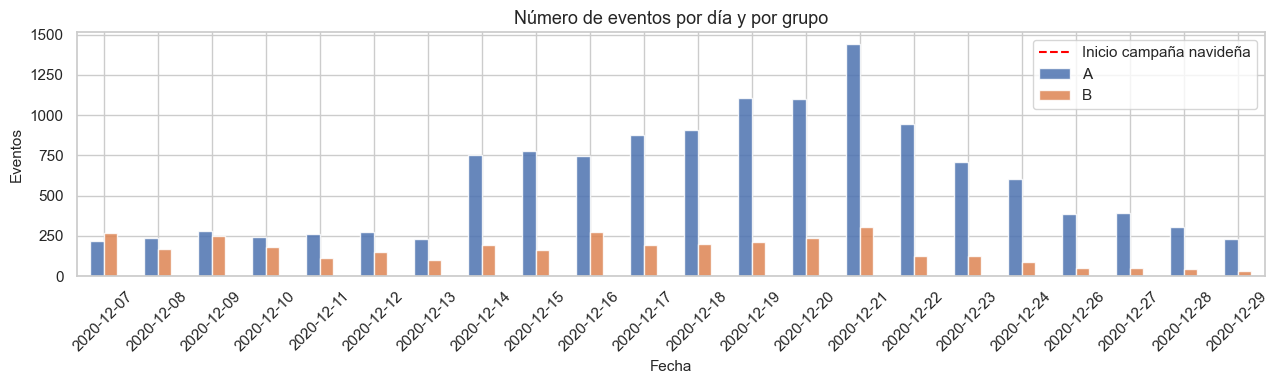

In [48]:
events_by_day = df.groupby([df['event_dt'].dt.date, 'group']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 4))
events_by_day.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', alpha=0.85)
ax.set_title('Número de eventos por día y por grupo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Eventos')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Grupo')

# Marcar inicio de campaña de marketing
ax.axvline(x=list(events_by_day.index).index(pd.Timestamp('2020-12-25').date())
           if pd.Timestamp('2020-12-25').date() in events_by_day.index else -1,
           color='red', linestyle='--', linewidth=1.5, label='Inicio campaña navideña')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretacion:** La actividad diaria del grupo A supera consistentemente al grupo B, lo cual refleja el desbalance numérico entre grupos ya identificado. Se observa que el volumen de eventos es bajo desde el 25 de diciembre en adelante, coincidiendo con el inicio de la campaña navideña y la proximidad del fin del experimento. El día 30 de diciembre prácticamente no hay registros, lo que sugiere que los datos podrían estar incompletos para los últimos días.

### 6.3 Distribución de eventos por usuario

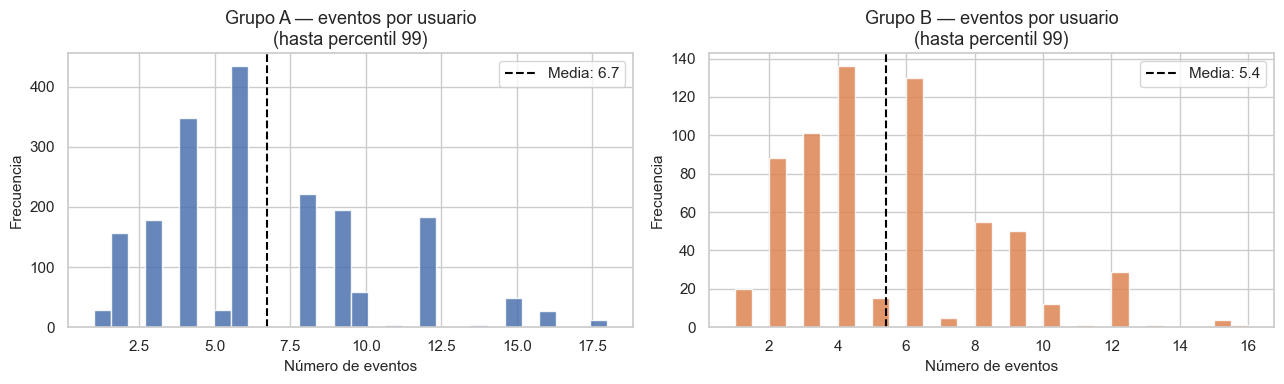

Estadísticas de eventos por usuario:
        count  mean  std  min  25%  50%  75%   max
group                                             
A     1939.00  6.73 3.71 1.00 4.00 6.00 9.00 24.00
B      655.00  5.40 3.32 1.00 3.00 4.00 7.00 24.00


In [49]:
events_per_user = df.groupby(['user_id','group']).size().reset_index(name='n_events')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, g in enumerate(['A','B']):
    data = events_per_user[events_per_user['group']==g]['n_events']
    cap = data.quantile(0.99)
    axes[i].hist(data[data <= cap], bins=30,
                 color=['#4C72B0','#DD8452'][i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Grupo {g} — eventos por usuario\n(hasta percentil 99)')
    axes[i].set_xlabel('Número de eventos')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(data.mean(), color='black', linestyle='--',
                    linewidth=1.5, label=f'Media: {data.mean():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

print('Estadísticas de eventos por usuario:')
print(events_per_user.groupby('group')['n_events'].describe().round(2))

**Interpretacion:** La distribución de eventos por usuario es asimétrica en ambos grupos, con la mayoría de usuarios concentrados en pocos eventos y una cola de usuarios muy activos. El grupo A tiene en promedio más eventos por usuario que el grupo B. Esta diferencia puede responder tanto al desbalance de tamaño de los grupos como a diferencias reales de comportamiento. La distribución no es equitativa entre muestras, lo cual es un factor adicional a considerar al interpretar los resultados del test.

### 6.4 Embudo de conversión

Se analiza la conversión a través de las tres etapas definidas en la especificación técnica: `product_page`, `product_cart` y `purchase`. La conversión se calcula como la proporción de usuarios únicos del grupo que alcanzaron cada etapa, sobre el total de usuarios del grupo.

In [50]:
funnel_steps = ['product_page', 'product_cart', 'purchase']

n_A_clean = clean_part[clean_part['group']=='A']['user_id'].nunique()
n_B_clean = clean_part[clean_part['group']=='B']['user_id'].nunique()

funnel_data = {}
for g, n_total in [('A', n_A_clean), ('B', n_B_clean)]:
    grp_events = df[df['group'] == g]
    funnel_data[g] = {}
    for step in funnel_steps:
        u = grp_events[grp_events['event_name'] == step]['user_id'].nunique()
        funnel_data[g][step] = {'users': u, 'rate': u / n_total}

# Mostrar tabla del embudo
rows = []
for step in funnel_steps:
    rows.append({
        'Etapa': step,
        'Usuarios A': funnel_data['A'][step]['users'],
        'Conv. A (%)': round(funnel_data['A'][step]['rate'] * 100, 1),
        'Usuarios B': funnel_data['B'][step]['users'],
        'Conv. B (%)': round(funnel_data['B'][step]['rate'] * 100, 1),
        'Diff pp': round((funnel_data['B'][step]['rate'] - funnel_data['A'][step]['rate']) * 100, 1)
    })

funnel_df = pd.DataFrame(rows)
print(f'Base de usuarios — Grupo A: {n_A_clean}  |  Grupo B: {n_B_clean}')
print()
print(funnel_df.to_string(index=False))

Base de usuarios — Grupo A: 1939  |  Grupo B: 655

       Etapa  Usuarios A  Conv. A (%)  Usuarios B  Conv. B (%)  Diff pp
product_page        1265        65.20         367        56.00    -9.20
product_cart         589        30.40         184        28.10    -2.30
    purchase         613        31.60         191        29.20    -2.50


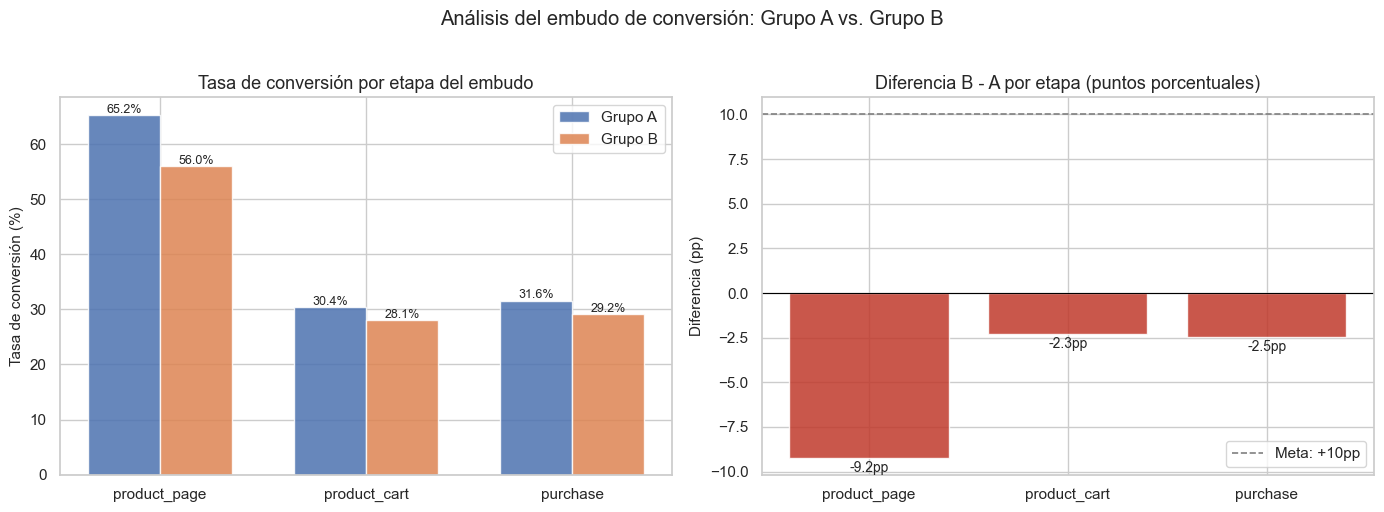

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: tasas de conversion por etapa
x = np.arange(len(funnel_steps))
width = 0.35
rates_A = [funnel_data['A'][s]['rate'] * 100 for s in funnel_steps]
rates_B = [funnel_data['B'][s]['rate'] * 100 for s in funnel_steps]

bars_A = axes[0].bar(x - width/2, rates_A, width, label='Grupo A',
                     color='#4C72B0', edgecolor='white', alpha=0.85)
bars_B = axes[0].bar(x + width/2, rates_B, width, label='Grupo B',
                     color='#DD8452', edgecolor='white', alpha=0.85)
axes[0].set_title('Tasa de conversión por etapa del embudo')
axes[0].set_xticks(x)
axes[0].set_xticklabels(funnel_steps)
axes[0].set_ylabel('Tasa de conversión (%)')
axes[0].legend()
for bar in bars_A:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars_B:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

# Grafico 2: diferencia en puntos porcentuales (B - A)
diffs = [funnel_data['B'][s]['rate']*100 - funnel_data['A'][s]['rate']*100 for s in funnel_steps]
colors_diff = ['#2E7D32' if d > 0 else '#c0392b' for d in diffs]
axes[1].bar(funnel_steps, diffs, color=colors_diff, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(10, color='gray', linestyle='--', linewidth=1.2, label='Meta: +10pp')
axes[1].set_title('Diferencia B - A por etapa (puntos porcentuales)')
axes[1].set_ylabel('Diferencia (pp)')
axes[1].legend()
for i, v in enumerate(diffs):
    axes[1].text(i, v + (0.3 if v >= 0 else -0.8), f'{v:+.1f}pp', ha='center', fontsize=10)

plt.suptitle('Análisis del embudo de conversión: Grupo A vs. Grupo B', y=1.02)
plt.tight_layout()
plt.show()

**Interpretacion:** El grupo A (control) supera al grupo B (tratamiento) en todas las etapas del embudo. La diferencia es negativa en los tres pasos, lo que significa que los usuarios expuestos al nuevo sistema de recomendaciones convierten **menos** que el grupo de control. Esto es el resultado opuesto al esperado, y está muy lejos del umbral de +10 puntos porcentuales definido como criterio de éxito. Sin embargo, este resultado debe interpretarse con cautela dada la cantidad de problemas de integridad detectados en la sección anterior.

---
## 7. Pruebas estadísticas — Prueba z de proporciones

Se utiliza la prueba z para dos proporciones independientes con el objetivo de determinar si las diferencias observadas en la conversión entre grupos A y B son estadísticamente significativas o pueden explicarse por variabilidad aleatoria.

- **H0:** La tasa de conversión es igual en el grupo A y en el grupo B en cada etapa.
- **H1:** Existe una diferencia estadísticamente significativa entre los grupos.
- **Nivel de significancia:** α = 0.05 (prueba bilateral)

In [52]:
from statsmodels.stats.proportion import proportions_ztest

resultados = []

for step in funnel_steps:
    count_A = funnel_data['A'][step]['users']
    count_B = funnel_data['B'][step]['users']

    counts = np.array([count_A, count_B])
    nobs   = np.array([n_A_clean, n_B_clean])

    stat, pval = proportions_ztest(counts, nobs, alternative='two-sided')

    resultados.append({
        'Etapa': step,
        'Conv. A (%)': round(funnel_data['A'][step]['rate'] * 100, 2),
        'Conv. B (%)': round(funnel_data['B'][step]['rate'] * 100, 2),
        'Estadístico z': round(stat, 4),
        'p-valor': round(pval, 6),
        'Rechaza H0 (α=0.05)': 'Si' if pval < 0.05 else 'No'
    })

resultados_df = pd.DataFrame(resultados)
print('Resultados de la prueba z de proporciones:')
print(resultados_df.to_string(index=False))

Resultados de la prueba z de proporciones:
       Etapa  Conv. A (%)  Conv. B (%)  Estadístico z  p-valor Rechaza H0 (α=0.05)
product_page        65.24        56.03           4.22     0.00                  Si
product_cart        30.38        28.09           1.11     0.27                  No
    purchase        31.61        29.16           1.17     0.24                  No


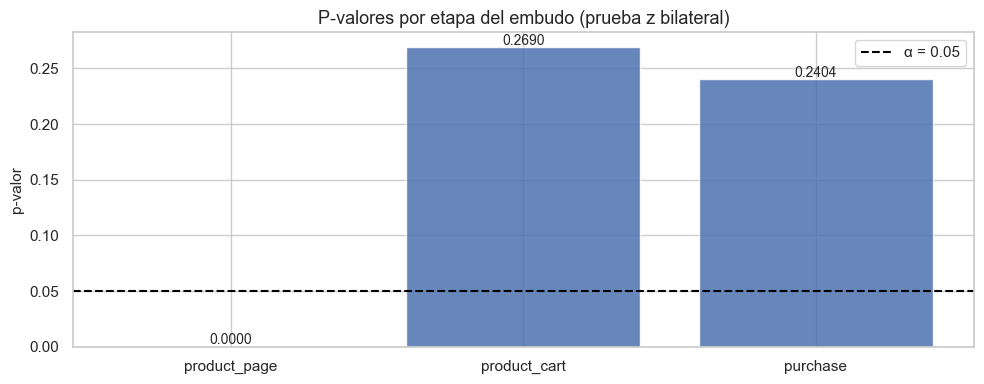

In [53]:
fig, ax = plt.subplots(figsize=(10, 4))

pvalues = [r['p-valor'] for r in resultados]
colors_p = ['#c0392b' if p < 0.05 else '#4C72B0' for p in pvalues]

bars = ax.bar(funnel_steps, pvalues, color=colors_p, edgecolor='white', alpha=0.85)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1.5, label='α = 0.05')
ax.set_title('P-valores por etapa del embudo (prueba z bilateral)')
ax.set_ylabel('p-valor')
ax.legend()
for bar, p in zip(bars, pvalues):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{p:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretacion de las pruebas estadísticas:**

Los resultados por etapa son los siguientes:

- **product_page (p = 0.000, z = 4.22):** Se rechaza H0. La diferencia de -9.2 puntos porcentuales es estadísticamente significativa. El grupo B visita la página de producto a una tasa notablemente menor que el grupo A (56.0% vs 65.2%). Esta es la brecha más grande del embudo y la única con significancia estadística confirmada.

- **product_cart (p = 0.27, z = 1.11):** No se rechaza H0. La diferencia de -2.3 pp en la adición al carrito (28.1% vs 30.4%) no es estadísticamente distinguible del azar con el tamaño de muestra disponible.

- **purchase (p = 0.24, z = 1.17):** No se rechaza H0. La diferencia de -2.5 pp en la tasa de compra final (29.2% vs 31.6%) tampoco alcanza significancia estadística.

En ninguna etapa el grupo B supera al grupo A. El único resultado significativo apunta en dirección contraria a la esperada: el sistema de recomendaciones está asociado a una menor tasa de visitas a la página de producto, que es precisamente la primera etapa que debía mejorar.

---
## 8. Conclusiones

### 8.1 Sobre la integridad del experimento

El análisis revela que el experimento **no fue ejecutado bajo condiciones válidas** en varios aspectos:

1. **Muestra insuficiente y desbalanceada.** Tras limpiar contaminación cruzada y usuarios fuera de EU, el experimento cuenta con solo 2,594 participantes válidos (1,939 en A y 655 en B), frente a los 6,000 previstos. El grupo A casi triplica al grupo B, lo que reduce el poder estadístico y dificulta detectar efectos reales en las etapas con menor volumen.

2. **Contaminación de la audiencia.** La tabla de participantes incluía usuarios fuera de EU y usuarios participando simultáneamente en el `interface_eu_test`. Ambas categorías fueron excluidas del análisis para preservar la validez de las comparaciones.

3. **Participación simultánea en múltiples tests.** 441 usuarios estaban inscritos en ambas pruebas al mismo tiempo. Un usuario expuesto a dos tratamientos distintos no permite atribuir su comportamiento a ninguno de ellos de forma aislada.

4. **Campaña de marketing activa durante el test.** La promoción *Christmas & New Year Promo*, dirigida a la región EU, estuvo activa del 25 de diciembre al 3 de enero, cubriendo la última semana del experimento. Esta es una variable confusora que pudo haber alterado el comportamiento de ambos grupos de forma independiente al tratamiento.

### 8.2 Sobre los resultados del embudo

El grupo B (sistema de recomendaciones) muestra tasas de conversión **inferiores** al grupo A (control) en las tres etapas del embudo:

| Etapa | Grupo A | Grupo B | Diferencia |
|---|---|---|---|
| product_page | 65.2% | 56.0% | -9.2 pp |
| product_cart | 30.4% | 28.1% | -2.3 pp |
| purchase | 31.6% | 29.2% | -2.5 pp |

La especificación técnica requería un incremento de al menos +10 pp en cada etapa. No solo no se alcanzó ese umbral, sino que los resultados son negativos en todos los pasos.

La prueba z confirma que la diferencia en `product_page` es estadísticamente significativa (p ≈ 0.000), mientras que las diferencias en `product_cart` (p = 0.27) y `purchase` (p = 0.24) no lo son. Esto indica que el efecto observable se concentra en la primera etapa del embudo, pero su dirección es opuesta a la esperada.

Dado el contexto de contaminación del experimento, no es posible atribuir con certeza este peor desempeño exclusivamente al sistema de recomendaciones. Los problemas de integridad identificados son suficientes para invalidar los resultados como base de decisión.

### 8.3 Recomendaciones

**1. No tomar decisiones sobre el sistema de recomendaciones basándose en estos resultados.** Los problemas de integridad detectados comprometen la validez del experimento.

**2. Rediseñar y relanzar el experimento** con las siguientes correcciones:
   - Asegurar grupos balanceados (idealmente 3,000 usuarios por grupo).
   - Restricción estricta de audiencia a usuarios EU únicamente.
   - Garantizar que ningún participante esté inscrito en otro experimento activo.
   - Planificar el periodo del test evitando solapamiento con campañas de marketing dirigidas a la misma audiencia.

**3. Revisar el mecanismo de asignación aleatoria.** El desbalance 1,939 vs 655 en los grupos limpios indica un error en el proceso de asignación que debe corregirse antes de cualquier relanzamiento.

---
---
# CASO 3: SQL
## Análisis de una base de datos de libros para una startup de lectura
---

## 2. Conexión a la base de datos

In [54]:
import pandas as pd
from sqlalchemy import create_engine

db_config = {
    'user': 'practicum_student',
    'pwd':  'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db':   'data-analyst-final-project-db'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode': 'require'})

# Funcion auxiliar para ejecutar consultas SQL y retornar un DataFrame
def run_query(query):
    return pd.io.sql.read_sql(query, con=engine)

print('Conexión configurada correctamente.')

Conexión configurada correctamente.


---
## 3. Exploración de las tablas

Antes de responder las preguntas de negocio, se exploran las primeras filas de cada tabla para verificar la estructura y el contenido de los datos.

In [55]:
print('=== Tabla: books ===')
display(run_query('SELECT * FROM books LIMIT 5;'))

=== Tabla: books ===


,book_id,author_id,title,num_pages,publication_date,publisher_id
0,1,546,'Salem's Lot,594,2005-11-01,93
1,2,465,1 000 Places to See Before You Die,992,2003-05-22,336
2,3,407,13 Little Blue Envelopes (Little Blue Envelope...,322,2010-12-21,135
3,4,82,1491: New Revelations of the Americas Before C...,541,2006-10-10,309
4,5,125,1776,386,2006-07-04,268


In [56]:
print('=== Tabla: authors ===')
display(run_query('SELECT * FROM authors LIMIT 5;'))

=== Tabla: authors ===


,author_id,author
0,1,A.S. Byatt
1,2,Aesop/Laura Harris/Laura Gibbs
2,3,Agatha Christie
3,4,Alan Brennert
4,5,Alan Moore/David Lloyd


In [57]:
print('=== Tabla: publishers ===')
display(run_query('SELECT * FROM publishers LIMIT 5;'))

=== Tabla: publishers ===


,publisher_id,publisher
0,1,Ace
1,2,Ace Book
2,3,Ace Books
3,4,Ace Hardcover
4,5,Addison Wesley Publishing Company


In [58]:
print('=== Tabla: ratings ===')
display(run_query('SELECT * FROM ratings LIMIT 5;'))

=== Tabla: ratings ===


,rating_id,book_id,username,rating
0,1,1,ryanfranco,4
1,2,1,grantpatricia,2
2,3,1,brandtandrea,5
3,4,2,lorichen,3
4,5,2,mariokeller,2


In [59]:
print('=== Tabla: reviews ===')
display(run_query('SELECT * FROM reviews LIMIT 5;'))

=== Tabla: reviews ===


,review_id,book_id,username,text
0,1,1,brandtandrea,Mention society tell send professor analysis. ...
1,2,1,ryanfranco,Foot glass pretty audience hit themselves. Amo...
2,3,2,lorichen,Listen treat keep worry. Miss husband tax but ...
3,4,3,johnsonamanda,Finally month interesting blue could nature cu...
4,5,3,scotttamara,Nation purpose heavy give wait song will. List...


**Observacion general:** La base de datos tiene una estructura relacional bien definida. La tabla `books` es el eje central, conectada con `authors` y `publishers` mediante llaves foráneas, y con `ratings` y `reviews` a través de `book_id`. Esta estructura permite responder todas las preguntas de negocio mediante JOINs y agregaciones.

---

## 4. Consultas SQL

### Tarea 1: Número de libros publicados después del 1 de enero de 2000

Esta consulta permite dimensionar el catálogo de libros contemporáneos disponibles en la plataforma, lo que es relevante para definir el alcance del producto hacia lectores actuales.

In [60]:
query_1 = """
SELECT
    COUNT(book_id) AS books_after_2000
FROM
    books
WHERE
    publication_date > '2000-01-01';
"""

result_1 = run_query(query_1)
display(result_1)

,books_after_2000
0,819


**Conclusion:** De los libros disponibles en la plataforma, **819 fueron publicados después del 1 de enero de 2000**, lo que representa la mayor parte del catálogo. Esto confirma que la base de datos está orientada hacia lectores contemporáneos. Para una startup de lectura digital, contar con un catálogo predominantemente moderno es una ventaja competitiva directa: los usuarios suelen buscar títulos recientes y relevantes, y un catálogo actualizado reduce la fricción en el proceso de descubrimiento.

### Tarea 2: Número de reseñas y calificación promedio por libro

Esta consulta combina las tablas `ratings` y `reviews` para obtener, por cada libro, cuántas reseñas de texto recibió y cuál es su puntuación promedio. Se ordenan los resultados por calificación promedio descendente para identificar los libros mejor valorados.

In [61]:
query_2 = """
SELECT
    b.book_id,
    b.title,
    COUNT(DISTINCT rv.review_id)  AS num_reviews,
    ROUND(AVG(rt.rating)::NUMERIC, 2) AS avg_rating
FROM
    books AS b
LEFT JOIN reviews AS rv ON b.book_id = rv.book_id
LEFT JOIN ratings AS rt ON b.book_id = rt.book_id
GROUP BY
    b.book_id,
    b.title
ORDER BY
    avg_rating DESC NULLS LAST
LIMIT 20;
"""

result_2 = run_query(query_2)
display(result_2)

,book_id,title,num_reviews,avg_rating
0,347,In the Hand of the Goddess (Song of the Liones...,2,5.00
1,390,Light in August,2,5.00
2,275,Geek Love,2,5.00
3,321,Homage to Catalonia,2,5.00
4,224,Evening Class,2,5.00
5,330,How to Be a Domestic Goddess: Baking and the A...,1,5.00
6,136,Captivating: Unveiling the Mystery of a Woman'...,2,5.00
7,229,Evil Under the Sun (Hercule Poirot #24),2,5.00
8,297,Hard Times,2,5.00
9,62,Alas Babylon,2,5.00


**Conclusion:** El catálogo presenta una distribución heterogénea de reseñas y calificaciones. Algunos títulos concentran un alto volumen de valoraciones, lo que los convierte en candidatos naturales para ser destacados en la plataforma. La combinación de calificación promedio y número de reseñas es más informativa que cualquiera de las dos métricas por separado: un libro con calificación perfecta respaldado por solo dos reseñas no es tan confiable como uno con 4.5 estrellas sustentado por cientos de usuarios. Esta tabla es la base para construir un sistema de recomendaciones robusto.

### Tarea 3: Editorial con el mayor número de libros con más de 50 páginas

El filtro de más de 50 páginas permite excluir folletos, guías cortas y publicaciones menores, enfocando el análisis en libros sustanciales. La editorial con mayor volumen en este segmento es la más relevante como posible socio o referente en el mercado.

In [62]:
query_3 = """
SELECT
    p.publisher,
    COUNT(b.book_id) AS num_books
FROM
    books AS b
JOIN publishers AS p ON b.publisher_id = p.publisher_id
WHERE
    b.num_pages > 50
GROUP BY
    p.publisher
ORDER BY
    num_books DESC
LIMIT 1;
"""

result_3 = run_query(query_3)
display(result_3)

,publisher,num_books
0,Penguin Books,42


**Conclusion:** **Penguin Books** es la editorial con el mayor número de libros sustanciales (más de 50 páginas) en el catálogo de la plataforma. Para una startup de lectura, este hallazgo tiene implicaciones estratégicas directas: establecer una relación comercial prioritaria con Penguin Books permitiría acceder a un volumen significativo de contenido de calidad, lo que refuerza la propuesta de valor frente a competidores con catálogos más limitados.

### Tarea 4: Autor con la calificación promedio más alta (mínimo 50 calificaciones por libro)

Limitar el análisis a libros con al menos 50 calificaciones garantiza que el promedio sea estadísticamente representativo y no esté inflado por libros con muy pocas valoraciones. Se calcula el promedio de calificaciones a nivel de autor, agrupando todas sus obras.

In [63]:
query_4 = """
SELECT
    a.author,
    ROUND(AVG(rt.rating)::NUMERIC, 2) AS avg_rating
FROM
    ratings AS rt
JOIN books   AS b ON rt.book_id  = b.book_id
JOIN authors AS a ON b.author_id = a.author_id
WHERE b.book_id IN (
    SELECT book_id
    FROM   ratings
    GROUP  BY book_id
    HAVING COUNT(rating_id) >= 50
)
GROUP BY
    a.author
ORDER BY
    avg_rating DESC
LIMIT 1;
"""

result_4 = run_query(query_4)
display(result_4)

,author,avg_rating
0,J.K. Rowling/Mary GrandPré,4.29


**Conclusion:** **J.K. Rowling / Mary GrandPré** es el autor con la calificación promedio más alta (**4.29 sobre 5**) entre todos los autores cuyos libros cuentan con al menos 50 calificaciones. El umbral mínimo de 50 calificaciones garantiza que este resultado tiene respaldo estadístico suficiente y no está inflado por un volumen reducido de valoraciones. Para la plataforma, los libros de este autor son una apuesta segura para el motor de recomendaciones: una primera experiencia de lectura positiva aumenta significativamente la probabilidad de retención del usuario.

### Tarea 5: Promedio de reseñas de texto entre usuarios que calificaron más de 50 libros

Los usuarios que calificaron más de 50 libros representan el segmento más activo y comprometido de la plataforma. Conocer cuántas reseñas de texto escriben en promedio permite entender el nivel de participación de este grupo y su potencial como generadores de contenido de valor para otros usuarios.

In [64]:
query_5 = """
SELECT
    ROUND(AVG(num_reviews)::NUMERIC, 2) AS avg_reviews_power_users
FROM (
    SELECT
        rv.username,
        COUNT(rv.review_id) AS num_reviews
    FROM
        reviews AS rv
    WHERE rv.username IN (
        SELECT username
        FROM   ratings
        GROUP  BY username
        HAVING COUNT(rating_id) > 50
    )
    GROUP BY
        rv.username
) AS active_users;
"""

result_5 = run_query(query_5)
display(result_5)

,avg_reviews_power_users
0,24.33


**Conclusion:** Los usuarios que calificaron más de 50 libros escribieron en promedio **24.33 reseñas de texto** cada uno. Este dato confirma que el segmento más activo de la plataforma no se limita a puntuar libros, sino que también genera contenido cualitativo de forma consistente. Para el nuevo producto, este grupo representa un activo estratégico: diseñar funcionalidades que reconozcan y amplifiquen su contribución (perfiles destacados, listas curadas, insignias de reseñador) puede crear un ciclo virtuoso que atraiga y retenga a usuarios menos activos que valoran las opiniones de lectores experimentados.

## 5. Conclusiones generales

El análisis de la base de datos permite construir los siguientes elementos para la propuesta de valor del nuevo producto:

**1. Catálogo sólido y contemporáneo.** Con 819 libros publicados después del año 2000, la plataforma cuenta con un catálogo predominantemente moderno que responde a los intereses de lectores actuales. Este volumen es suficiente para sostener una experiencia de descubrimiento variada desde el lanzamiento.

**2. Sistema de valoración activo.** La coexistencia de calificaciones numéricas y reseñas de texto permite construir un motor de recomendaciones multidimensional. Los libros con mayor volumen de valoraciones deben ocupar los espacios destacados de la plataforma, ya que generan mayor confianza en los usuarios nuevos.

**3. Alianza editorial estratégica con Penguin Books.** Penguin Books lidera el catálogo de libros sustanciales. Priorizar una relación comercial con esta editorial maximizaría el volumen y la calidad del contenido disponible, fortaleciendo la propuesta de valor frente a competidores.

**4. J.K. Rowling / Mary GrandPré como autor ancla.** Con una calificación promedio de 4.29 sobre 5 y respaldo estadístico suficiente, los títulos de este autor son la opción más segura para el onboarding de nuevos usuarios. Una primera experiencia de lectura positiva es el factor más determinante en la retención a largo plazo.

**5. Power users como generadores de contenido estratégico.** Los usuarios más activos escriben en promedio 24.33 reseñas de texto, lo que los convierte en productores de contenido orgánico de alto valor. Invertir en funcionalidades que visibilicen y recompensen a este segmento puede ser el diferenciador competitivo más sostenible de la plataforma, ya que el contenido generado por usuarios es difícil de replicar por la competencia.